**Nom :** [Double-cliquez ici pour entrer votre nom]

**Prénom :** [Double-cliquez ici pour entrer votre prénom]

# Mini-projet IA Chimie — SVM et comparaison avec les plus proches voisins

## Objectif

Ce notebook introduit une méthode classique de Machine Learning : le **SVM**  
(**Support Vector Machine**, ou **machine à vecteurs de support**).

L'objectif est de prédire si une molécule est **toxique** ou **non toxique** à partir de propriétés moléculaires simples.

On comparera aussi rapidement SVM avec la méthode des **k plus proches voisins**.

---

## Idée intuitive

### k plus proches voisins, ou k-NN

Pour classer une nouvelle molécule, on regarde les molécules déjà connues qui lui ressemblent le plus.

> Si ses voisins les plus proches sont toxiques, on la classe toxique.

### SVM

Le SVM ne regarde pas directement les voisins.  
Il cherche une **frontière de séparation** entre les classes.

> Il essaie de tracer la meilleure limite possible entre molécules toxiques et non toxiques.

Les points les plus proches de la frontière sont appelés :

> **vecteurs de support**

Ce sont eux qui déterminent principalement la position de la frontière.

## 1. Importation des bibliothèques

In [29]:
# Si besoin dans Google Colab :
# !pip install rdkit-pypi scikit-learn pandas matplotlib numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    classification_report
)

## 2. Petite base pédagogique de molécules

La base est volontairement simple pour comprendre la méthode.

- `0` : non toxique ou faible toxicité dans ce contexte pédagogique ;
- `1` : toxique ou substance préoccupante dans ce contexte pédagogique.

⚠️ Cette classification est simplifiée : elle sert uniquement à l'apprentissage.

In [30]:
data = [
    ("Ethanol", "CCO", 0),
    ("Acetone", "CC(=O)C", 0),
    ("Acide acetique", "CC(=O)O", 0),
    ("Glycerol", "C(C(CO)O)O", 0),
    ("Glucose", "C(C1C(C(C(C(O1)O)O)O)O)O", 0),
    ("Cafeine", "Cn1cnc2n(C)c(=O)n(C)c(=O)c12", 0),
    ("Paracetamol", "CC(=O)NC1=CC=C(C=C1)O", 0),
    ("Aspirine", "CC(=O)OC1=CC=CC=C1C(=O)O", 0),
    ("Vanilline", "COC1=C(C=CC(=C1)C=O)O", 0),
    ("Acide citrique", "C(C(=O)O)C(CC(=O)O)(C(=O)O)O", 0),

    ("Benzene", "c1ccccc1", 1),
    ("Toluene", "Cc1ccccc1", 1),
    ("Phenol", "c1ccc(cc1)O", 1),
    ("Aniline", "c1ccc(cc1)N", 1),
    ("Chloroforme", "C(Cl)(Cl)Cl", 1),
    ("Tetrachloromethane", "C(Cl)(Cl)(Cl)Cl", 1),
    ("Chlorure de vinyle", "C=CCl", 1),
    ("Formaldehyde", "C=O", 1),
    ("Nitrobenzene", "C1=CC=C(C=C1)[N+](=O)[O-]", 1),
    ("Acrylonitrile", "C=CC#N", 1),
]

df = pd.DataFrame(data, columns=["Nom", "SMILES", "Toxique"])
df

,Nom,SMILES,Toxique
0,Ethanol,CCO,0
1,Acetone,CC(=O)C,0
2,Acide acetique,CC(=O)O,0
3,Glycerol,C(C(CO)O)O,0
4,Glucose,C(C1C(C(C(C(O1)O)O)O)O)O,0
5,Cafeine,Cn1cnc2n(C)c(=O)n(C)c(=O)c12,0
6,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,0
7,Aspirine,CC(=O)OC1=CC=CC=C1C(=O)O,0
8,Vanilline,COC1=C(C=CC(=C1)C=O)O,0
9,Acide citrique,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,0


## 3. Calcul de descripteurs moléculaires avec RDKit

In [31]:
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
    from rdkit.Chem.Draw import MolsToGridImage
    RDKIT_AVAILABLE = True
except ImportError:
    RDKIT_AVAILABLE = False
    print("RDKit n'est pas installé. Dans Google Colab : !pip install rdkit-pypi")

RDKIT_AVAILABLE

True

In [32]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms()
    }

desc = df["SMILES"].apply(compute_descriptors)
desc_df = pd.DataFrame(list(desc))
df_desc = pd.concat([df, desc_df], axis=1)
df_desc

,Nom,SMILES,Toxique,MolWt,LogP,TPSA,HBD,HBA,RotBonds,HeavyAtoms
0,Ethanol,CCO,0,46.069,-0.00140,20.23,1,1,0,3
1,Acetone,CC(=O)C,0,58.080,0.59530,17.07,0,1,0,4
2,Acide acetique,CC(=O)O,0,60.052,0.09090,37.30,1,1,0,4
3,Glycerol,C(C(CO)O)O,0,92.094,-1.66810,60.69,3,3,2,6
4,Glucose,C(C1C(C(C(C(O1)O)O)O)O)O,0,180.156,-3.22140,110.38,5,6,1,12
5,Cafeine,Cn1cnc2n(C)c(=O)n(C)c(=O)c12,0,194.194,-1.02930,61.82,0,3,0,14
6,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,0,151.165,1.35060,49.33,2,2,1,11
7,Aspirine,CC(=O)OC1=CC=CC=C1C(=O)O,0,180.159,1.31010,63.60,1,3,2,13
8,Vanilline,COC1=C(C=CC(=C1)C=O)O,0,152.149,1.21330,46.53,1,3,2,11
9,Acide citrique,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,0,192.123,-1.24850,132.13,4,4,5,13


## 4. Visualisation des molécules

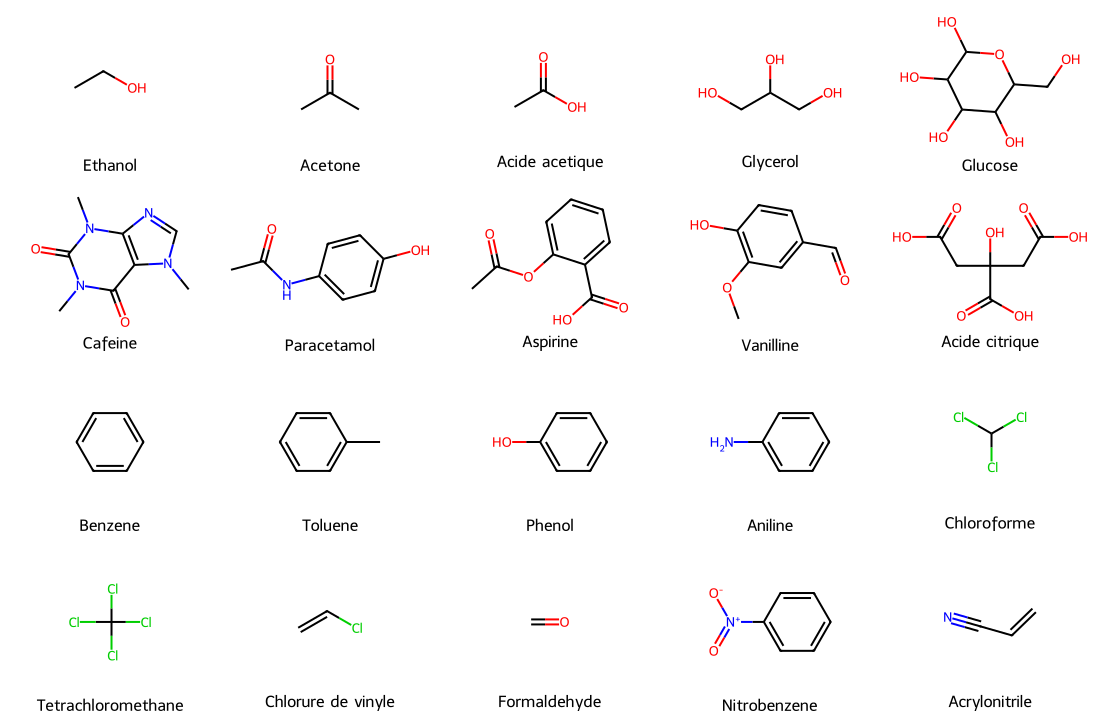

In [33]:
mols = [Chem.MolFromSmiles(s) for s in df["SMILES"]]
img = MolsToGridImage(mols, legends=df["Nom"].tolist(), molsPerRow=5, subImgSize=(220, 180))
display(img)

## 5. Visualisation dans le plan LogP / masse molaire

Pour expliquer SVM, on commence avec seulement deux propriétés :

- LogP ;
- masse molaire.

Cela permet de visualiser une frontière de séparation.

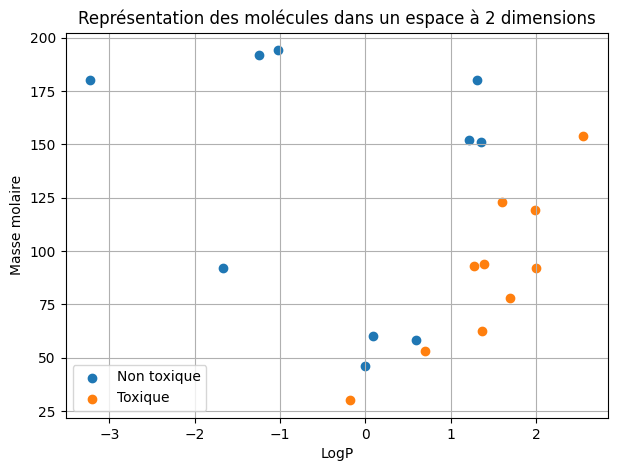

In [34]:
plt.figure(figsize=(7, 5))
for classe, label in [(0, "Non toxique"), (1, "Toxique")]:
    subset = df_desc[df_desc["Toxique"] == classe]
    plt.scatter(subset["LogP"], subset["MolWt"], label=label)

plt.xlabel("LogP")
plt.ylabel("Masse molaire")
plt.title("Représentation des molécules dans un espace à 2 dimensions")
plt.legend()
plt.grid(True)
plt.show()

### Analyse de la distribution en 2D

**Question 1 : En regardant le graphique 2D ci-dessus, pensez-vous qu'il soit possible de tracer une simple *ligne droite parfaite* pour séparer toutes les molécules toxiques des non-toxiques sans faire d'erreur ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

### 💡 L'analogie de l'Autoroute (SVM)

Avant de lancer le code, voici comment comprendre intuitivement l'algorithme **SVM (Machine à Vecteurs de Support)** :

Imaginez que les molécules non-toxiques sont des villages bleus, et les toxiques des villages rouges. 
Le but du SVM n'est pas juste de tracer une ligne de démarcation au hasard. Son but est de **construire l'autoroute la plus large possible** pour séparer les deux zones.

- Plus l'autoroute est large, plus le modèle est "sûr" de lui.
- Les **Vecteurs de Support** sont les villages qui se trouvent *exactement sur les bandes d'arrêt d'urgence*. Ce sont eux qui bloquent l'élargissement de l'autoroute.
- Si vous supprimez un village loin de l'autoroute, ça ne change rien. Mais si vous déplacez un "vecteur de support", toute l'autoroute doit être redessinée !

## 6. Entraînement d'un SVM simple

Nous utilisons un SVM avec noyau linéaire.

Cela signifie que le modèle cherche une frontière de séparation aussi simple que possible.

In [35]:
features_2d = ["LogP", "MolWt"]

X = df_desc[features_2d]
y = df_desc["Toxique"]

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X, y, df_desc["Nom"],
    test_size=0.35,
    random_state=42,
    stratify=y
)

svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", probability=True, random_state=42))
])

svm_linear.fit(X_train, y_train)

y_pred = svm_linear.predict(X_test)
y_proba = svm_linear.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Molécule": names_test.values,
    "Classe réelle": y_test.values,
    "Classe prédite SVM": y_pred,
    "Probabilité toxique": y_proba
}).sort_values("Probabilité toxique", ascending=False)

display(results)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_proba))
print()
print(classification_report(y_test, y_pred, target_names=["Non toxique", "Toxique"]))

,Molécule,Classe réelle,Classe prédite SVM,Probabilité toxique
4,Chloroforme,1,1,0.755610
3,Aniline,1,1,0.616645
0,Vanilline,0,1,0.543513
2,Aspirine,0,1,0.541403
1,Formaldehyde,1,0,0.303907
5,Glycerol,0,0,0.065589
6,Glucose,0,0,0.009438


Accuracy : 0.5714285714285714
ROC-AUC : 0.8333333333333333

              precision    recall  f1-score   support

 Non toxique       0.67      0.50      0.57         4
     Toxique       0.50      0.67      0.57         3

    accuracy                           0.57         7
   macro avg       0.58      0.58      0.57         7
weighted avg       0.60      0.57      0.57         7



## 7. Visualisation de la frontière de séparation du SVM

Cette cellule permet de voir la zone classée comme toxique ou non toxique.

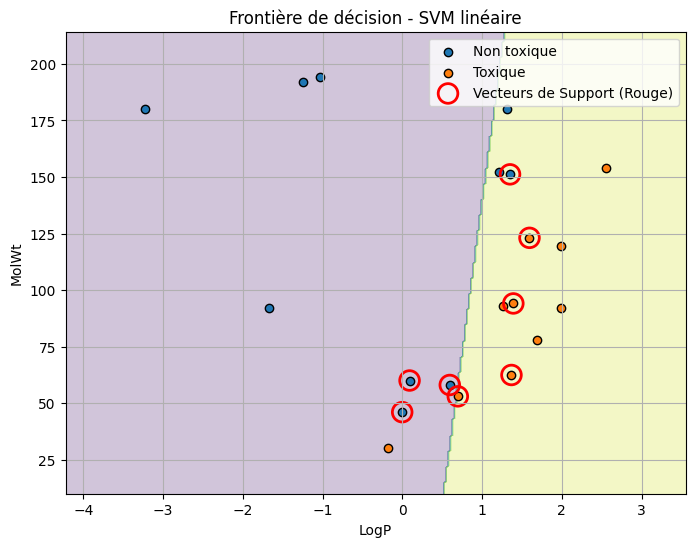

In [36]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 20, X.iloc[:, 1].max() + 20

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns)
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25)

    for classe, label in [(0, "Non toxique"), (1, "Toxique")]:
        subset = X[y == classe]
        plt.scatter(subset.iloc[:, 0], subset.iloc[:, 1], label=label, edgecolor="k")

    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(title)
    # [NOUVEAU PÉDAGOGIQUE] : Entourer les vecteurs de support pour le SVM
    if hasattr(model, 'named_steps') and 'svm' in model.named_steps:
        try:
            sv_indices = model.named_steps['svm'].support_
            # X_train est une variable globale définie lors du train_test_split
            sv_points = X_train.iloc[sv_indices]
            plt.scatter(sv_points.iloc[:, 0], sv_points.iloc[:, 1], 
                        s=200, facecolors='none', edgecolors='red', linewidths=2, 
                        label="Vecteurs de Support (Rouge)")
        except Exception as e:
            pass

    plt.legend()
    plt.grid(True)
    plt.show()

plot_decision_boundary(svm_linear, X, y, "Frontière de décision - SVM linéaire")

**Question 2 : Le SVM Linéaire a tracé une droite. Essayez de repérer mentalement les "vecteurs de support" (les points les plus proches de la frontière). Que se passerait-il si on supprimait une molécule toxique très éloignée de la frontière (tout en haut à droite du graphique) : la droite bougerait-elle ? Pourquoi ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

### 💡 Le Vote du Voisinage (k-NN)

L'algorithme des **k plus proches voisins (k-NN)** fonctionne de manière totalement différente. Il n'y a pas d'autoroute ni de frontière mathématique globale.

C'est un algorithme purement basé sur le **voisinage chimique** :
1. On prend une nouvelle molécule inconnue.
2. On cherche les **k=3** molécules les plus proches d'elle sur le graphique (celles qui ont presque la même masse et le même LogP).
3. On fait voter ces 3 voisins à la majorité : "Si 2 de mes voisins sont toxiques et 1 est sain, alors je suis très probablement toxique."

C'est pour cela que la frontière du k-NN ne sera pas une ligne droite, mais plutôt une série de "bulles" autour des groupes de molécules.

## 8. Comparaison avec les k plus proches voisins

Le modèle k-NN classe une molécule en regardant ses voisins les plus proches.

Ici, on utilise `k = 3`.

In [37]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Molécule": names_test.values,
    "Réel": y_test.values,
    "SVM": y_pred,
    "Proba SVM": y_proba,
    "k-NN": y_pred_knn,
    "Proba k-NN": y_proba_knn
})

display(comparison)

print("SVM ROC-AUC :", roc_auc_score(y_test, y_proba))
print("k-NN ROC-AUC :", roc_auc_score(y_test, y_proba_knn))

,Molécule,Réel,SVM,Proba SVM,k-NN,Proba k-NN
0,Vanilline,0,1,0.543513,1,0.666667
1,Formaldehyde,1,0,0.303907,0,0.000000
2,Aspirine,0,1,0.541403,1,0.666667
3,Aniline,1,1,0.616645,1,1.000000
4,Chloroforme,1,1,0.755610,1,1.000000
5,Glycerol,0,0,0.065589,0,0.000000
6,Glucose,0,0,0.009438,0,0.000000


SVM ROC-AUC : 0.8333333333333333
k-NN ROC-AUC : 0.75


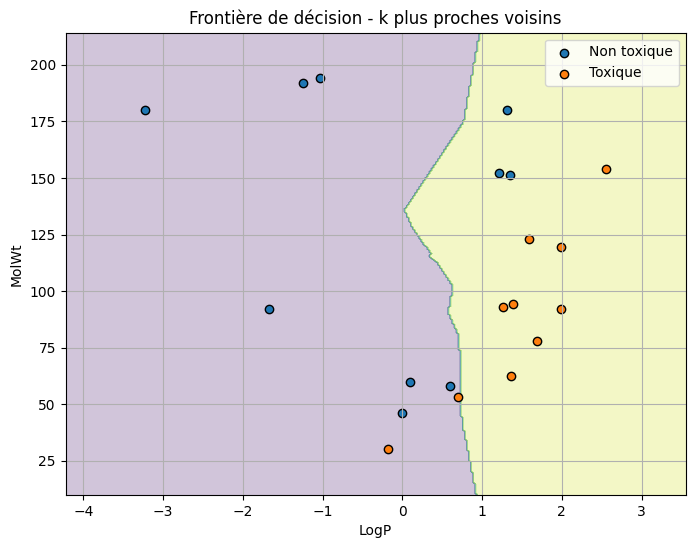

In [38]:
plot_decision_boundary(knn, X, y, "Frontière de décision - k plus proches voisins")

### Comparaison Visuelle SVM vs k-NN

**Question 3 : Quelle différence visuelle fondamentale observez-vous entre la frontière rigide du SVM linéaire et la frontière en "bulles" du k-NN ? Laquelle vous semble "coller" le plus à la réalité de ces données chimiques ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

## 9. SVM avec plusieurs descripteurs

Dans une vraie application, on utilise plus que deux propriétés.

On ajoute ici :

- masse molaire ;
- LogP ;
- TPSA ;
- donneurs H ;
- accepteurs H ;
- liaisons rotatives ;
- nombre d'atomes lourds.

In [39]:
features = ["MolWt", "LogP", "TPSA", "HBD", "HBA", "RotBonds", "HeavyAtoms"]

X_full = df_desc[features]
y = df_desc["Toxique"]

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X_full, y, df_desc["Nom"],
    test_size=0.35,
    random_state=42,
    stratify=y
)

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

svm_rbf.fit(X_train, y_train)

y_pred = svm_rbf.predict(X_test)
y_proba = svm_rbf.predict_proba(X_test)[:, 1]

results_full = pd.DataFrame({
    "Molécule": names_test.values,
    "Classe réelle": y_test.values,
    "Classe prédite": y_pred,
    "Probabilité toxique": y_proba
}).sort_values("Probabilité toxique", ascending=False)

display(results_full)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_proba))
print()
print(classification_report(y_test, y_pred, target_names=["Non toxique", "Toxique"]))

,Molécule,Classe réelle,Classe prédite,Probabilité toxique
4,Chloroforme,1,1,0.765228
3,Aniline,1,1,0.580127
0,Vanilline,0,0,0.348804
6,Glucose,0,0,0.336005
2,Aspirine,0,0,0.298501
1,Formaldehyde,1,0,0.271937
5,Glycerol,0,0,0.260376


Accuracy : 0.8571428571428571
ROC-AUC : 0.75

              precision    recall  f1-score   support

 Non toxique       0.80      1.00      0.89         4
     Toxique       1.00      0.67      0.80         3

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7



### L'importance de la Normalisation

**Question 4 : Dans le code ci-dessus, on utilise `StandardScaler()`. Pourquoi est-il absolument indispensable de normaliser les données (LogP qui varie de -2 à 5 vs Masse molaire qui varie de 50 à 500) pour des algorithmes basés sur la géométrie des distances comme le SVM ou le k-NN ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

## 10. Matrice de confusion

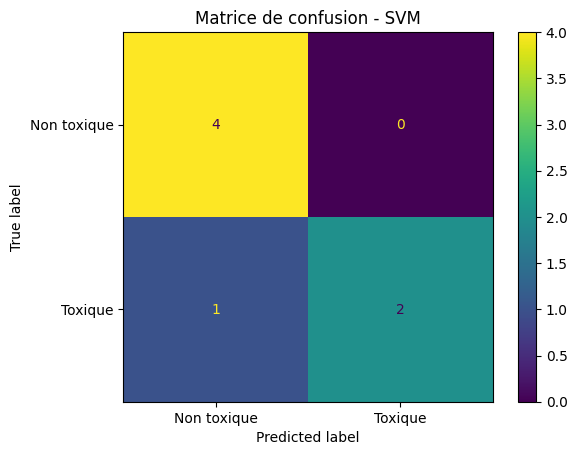

In [40]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non toxique", "Toxique"])
disp.plot()
plt.title("Matrice de confusion - SVM")
plt.show()

## 11. Courbe ROC

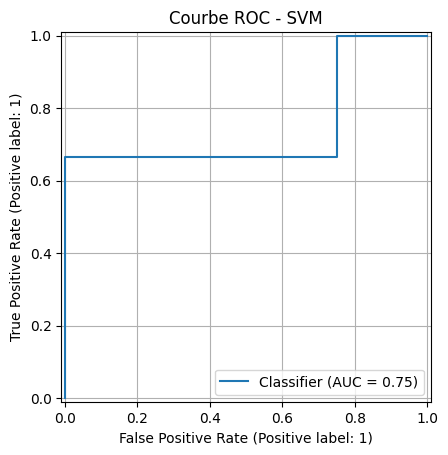

In [41]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Courbe ROC - SVM")
plt.grid(True)
plt.show()

## 12. Tester une molécule choisie

Changez le nom et le SMILES de la molécule.

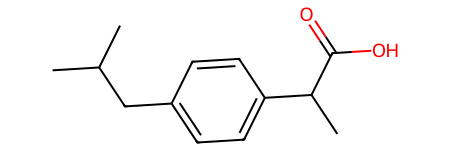

Molécule : Ibuprofene
SMILES : CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
Probabilité estimée de toxicité : 0.351
Classe prédite : Non toxique


,MolWt,LogP,TPSA,HBD,HBA,RotBonds,HeavyAtoms
0,206.285,3.0732,37.3,1,1,4,15


In [42]:
nom_molecule = "Ibuprofene"
smiles_molecule = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"

mol = Chem.MolFromSmiles(smiles_molecule)
display(mol)

desc_new = compute_descriptors(smiles_molecule)
x_new = pd.DataFrame([desc_new])[features]

proba_tox = svm_rbf.predict_proba(x_new)[0, 1]
prediction = svm_rbf.predict(x_new)[0]

print("Molécule :", nom_molecule)
print("SMILES :", smiles_molecule)
print("Probabilité estimée de toxicité :", round(proba_tox, 3))
print("Classe prédite :", "Toxique" if prediction == 1 else "Non toxique")
display(x_new)

### Le problème de la Boîte Noire

**Question 5 : Le SVM (surtout avec noyau RBF) est souvent vu comme une méthode "boîte noire". Pourquoi est-il beaucoup plus difficile d'expliquer *pourquoi* le modèle a pris cette décision à un pharmacologue, comparé à une Random Forest ou à un Arbre de décision ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

## 13. Question de synthèse

**Question 6 : Avec la petite base de données de 20 molécules utilisée aujourd'hui, pensez-vous pouvoir faire aveuglément confiance aux prédictions de votre modèle pour évaluer la toxicité d'un nouveau médicament ? Pourquoi ? (Pensez à la représentativité).**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

## 14. Conclusion pédagogique

Le SVM est une méthode intermédiaire intéressante entre les modèles simples et les réseaux de neurones.

- Il est plus sophistiqué que Naive Bayes.
- Il peut être plus performant qu'un modèle linéaire simple.
- Il est cependant moins directement interprétable qu'un arbre de décision ou qu'une Random Forest.

Message important :

> En chimie, il faut comparer plusieurs modèles avant de choisir une méthode. Le modèle le plus complexe n'est pas toujours le plus utile.

---

# 15. Rendu du travail

Puisque vous avez répondu directement dans les cellules bleues de ce document, **vous n'avez pas de compte rendu séparé à rendre**.

Assurez-vous simplement :
1. D'avoir bien indiqué vos noms et prénoms au tout début du notebook.
2. D'avoir répondu à toutes les questions dans les cellules bleues.
3. D'enregistrer ce fichier `.ipynb`.

Déposez ensuite directement ce notebook complété sur la plateforme de votre cours.